# Notebook 03 – Feature Engineering
Derive ≥5 clinically meaningful features and validate each.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_prep import generate_synthetic_data, clean_data, impute_missing_values
from src.features import engineer_features, get_feature_names

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

DATA_PATH = '../data/processed/heart_clean.csv'
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
else:
    df = impute_missing_values(clean_data(generate_synthetic_data()))

print("Data loaded:", df.shape)


Data loaded: (303, 14)


In [2]:
df_feat = engineer_features(df)
new_features = get_feature_names(df, df_feat)
print(f"New features created ({len(new_features)}):", sorted(new_features))
assert len(new_features) >= 5, "Contract violation: need at least 5 new features!"
print("✅ Contract satisfied: ≥5 new features engineered.")


New features created (8): ['age_risk_bin', 'age_thalach_ratio', 'bp_chol_product', 'chol_age_ratio', 'exang_oldpeak_interact', 'high_risk_flag', 'st_depression_flag', 'vessel_thal_score']
✅ Contract satisfied: ≥5 new features engineered.


## Feature Validation – Relationship with Target

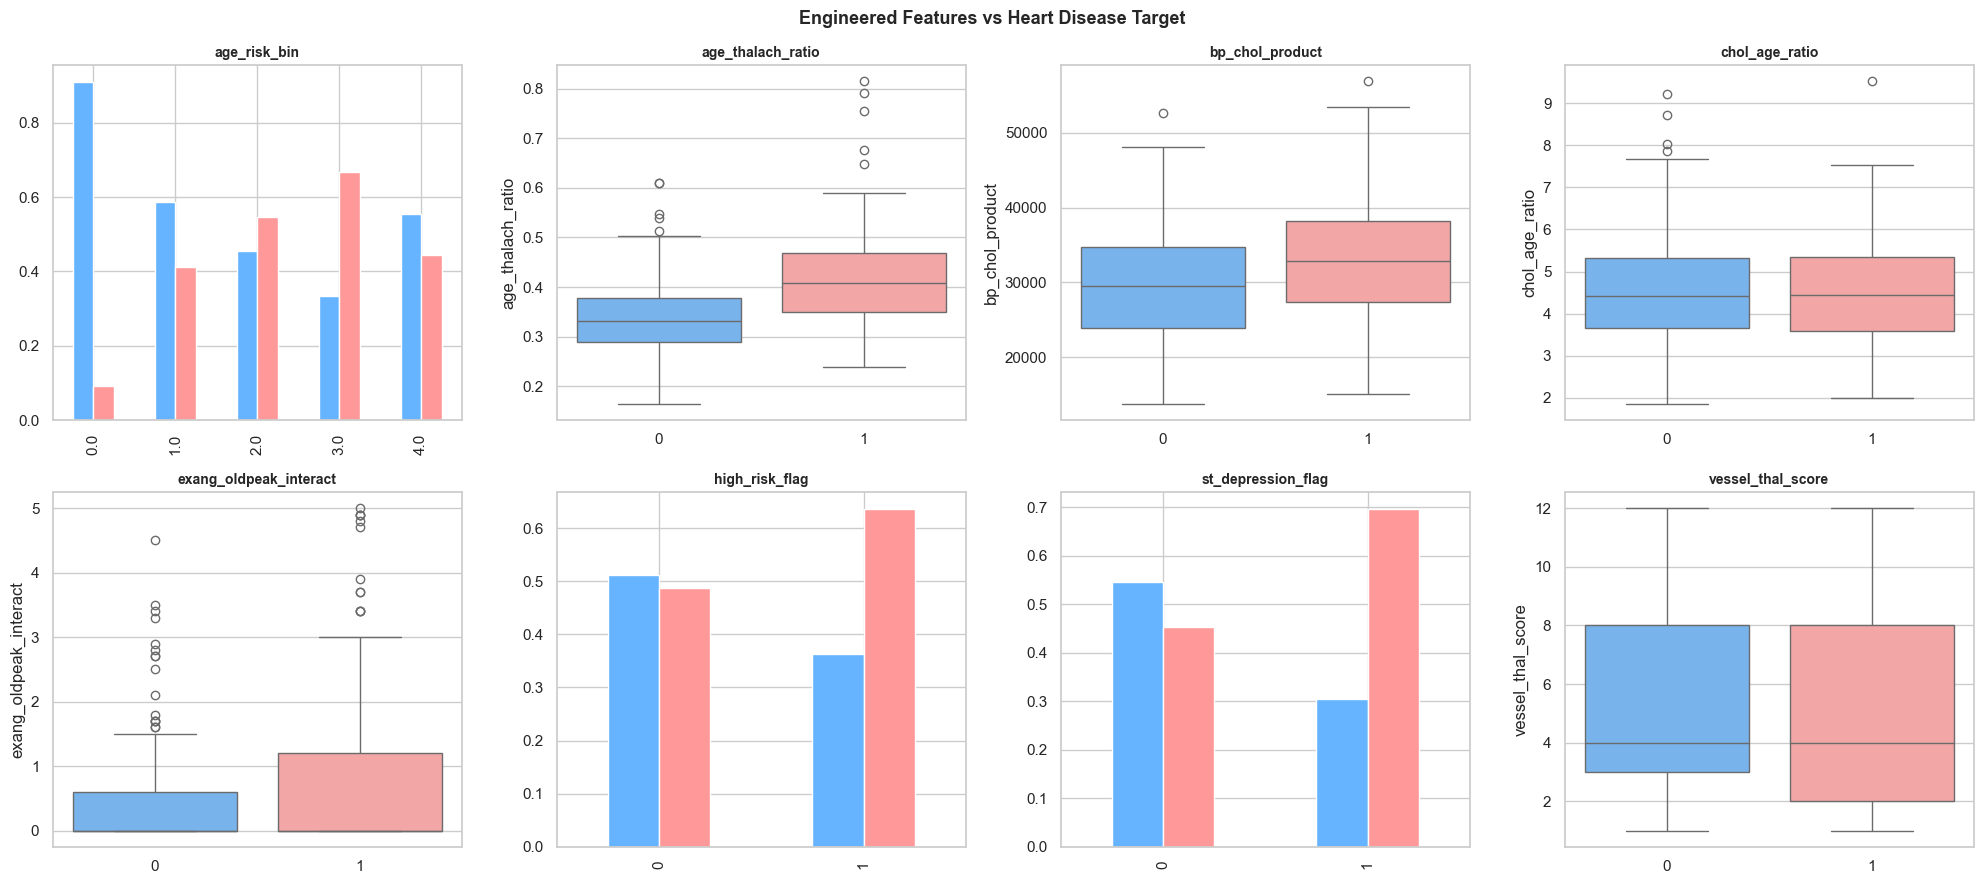

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feat in enumerate(sorted(new_features)):
    if df_feat[feat].nunique() > 5:
        sns.boxplot(data=df_feat, x='target', y=feat, ax=axes[i],
                    palette=['#66b3ff','#ff9999'])
    else:
        ct = pd.crosstab(df_feat[feat], df_feat['target'], normalize='index')
        ct.plot(kind='bar', ax=axes[i], color=['#66b3ff','#ff9999'], legend=False)
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(new_features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Engineered Features vs Heart Disease Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
df_feat.to_csv('../data/processed/heart_engineered.csv', index=False)
print("Engineered dataset saved.")
print("Final shape:", df_feat.shape)
df_feat[sorted(new_features)].describe().round(3)


Engineered dataset saved.
Final shape: (303, 22)


,age_risk_bin,age_thalach_ratio,bp_chol_product,chol_age_ratio,exang_oldpeak_interact,high_risk_flag,st_depression_flag,vessel_thal_score
count,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000
mean,1.848,0.378,31308.149,4.573,0.621,0.073,0.185,5.192
std,0.923,0.098,8537.314,1.288,1.080,0.260,0.389,3.193
min,0.000,0.164,13734.000,1.853,0.000,0.000,0.000,1.000
25%,1.000,0.311,25545.500,3.615,0.000,0.000,0.000,2.261
50%,2.000,0.366,31050.000,4.438,0.000,0.000,0.000,4.000
75%,2.000,0.431,35854.500,5.332,0.850,0.000,0.000,8.000
max,4.000,0.815,56875.000,9.514,5.000,1.000,1.000,12.000
